In [ ]:
import pandas as pd
import numpy as np

In [ ]:
np.random.seed(42)
n=1000

In [ ]:
data = pd.DataFrame({"user_id":range(1,n+1), "signup_date":pd.to_datetime("2023-01-01")+pd.to_timedelta(np.random.randint(0,365,n),unit="D"),
                     "last_active_days_ago":np.random.randint(0,30,n),"plan_type":np.random.choice(["free","basic","premium"],n,p=[0.5,0.3,0.2]),
                     "monthly_usage":np.random.randint(0,50,n),"feature_A_used":np.random.choice([0,1],n,p=[0.4,0.6]),"feature_B_used":
                     np.random.choice([0,1],n,p=[0.5,0.5]),"support_tickets":np.random.randint(0,5,n)})

data["churned"] = np.where((data["last_active_days_ago"]>10)&(data["monthly_usage"]<5),1,0)
data.to_csv("churn_data.csv",index=False)

data.head()

,user_id,signup_date,last_active_days_ago,plan_type,monthly_usage,feature_A_used,feature_B_used,support_tickets,churned
0,1,2023-04-13,10,free,13,0,1,2,0
1,2,2023-12-15,2,premium,29,1,1,1,0
2,3,2023-09-28,0,free,40,0,1,1,0
3,4,2023-04-17,5,free,3,1,0,2,0
4,5,2023-03-13,17,free,3,1,0,0,1


In [ ]:
data.shape

(1000, 9)

In [ ]:
df = pd.read_csv("churn_data.csv")

In [ ]:
df.corr(numeric_only=True)

,user_id,last_active_days_ago,monthly_usage,feature_A_used,feature_B_used,support_tickets,churned
user_id,1.000000,0.047842,-0.017012,-0.021827,-0.011162,0.046232,-0.016749
last_active_days_ago,0.047842,1.000000,-0.014778,-0.005853,-0.001517,0.034365,0.168126
monthly_usage,-0.017012,-0.014778,1.000000,0.021296,0.022772,-0.009165,-0.415389
feature_A_used,-0.021827,-0.005853,0.021296,1.000000,-0.044549,-0.055547,0.018857
feature_B_used,-0.011162,-0.001517,0.022772,-0.044549,1.000000,0.007307,0.019673
support_tickets,0.046232,0.034365,-0.009165,-0.055547,0.007307,1.000000,-0.028539
churned,-0.016749,0.168126,-0.415389,0.018857,0.019673,-0.028539,1.000000


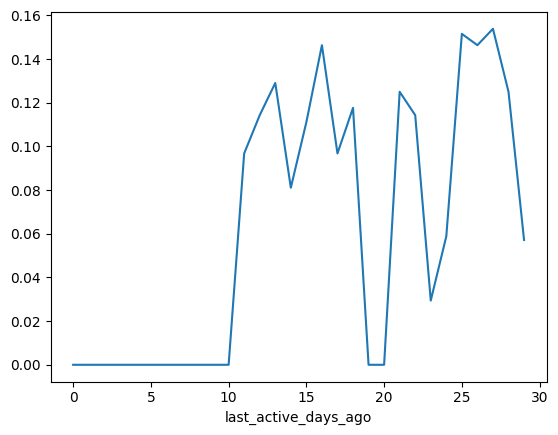

In [ ]:
import matplotlib.pyplot as plt

df.groupby("last_active_days_ago")["churned"].mean().plot()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["last_active_days_ago", "monthly_usage", "support_tickets"]]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.98

In [ ]:
df["risk_score"] = (df["last_active_days_ago"] * 0.4 +(50 - df["monthly_usage"]) * 0.3 +
                    df["support_tickets"] * 0.3)

df["risk_level"] = pd.cut(df["risk_score"],
                         bins=[-1,10,20,100],
                         labels=["Low","Medium","High"])

In [ ]:
df["risk_level"].value_counts()

,count
risk_level,
Medium,594
Low,260
High,146


In [ ]:
model.coef_

array([[ 0.4060419 , -1.49470479, -0.06034808]])

In [ ]:
df["predicted"]= model.predict(X)

In [ ]:
df.groupby("risk_level")["predicted"].mean()

/tmp/ipykernel_2459/1299608573.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("risk_level")["predicted"].mean()


,predicted
risk_level,
Low,0.000000
Medium,0.011785
High,0.369863


In [ ]:
df

,user_id,signup_date,last_active_days_ago,plan_type,monthly_usage,feature_A_used,feature_B_used,support_tickets,churned,risk_score,risk_level,predicted
0,1,2023-04-13,10,free,13,0,1,2,0,15.7,Medium,0
1,2,2023-12-15,2,premium,29,1,1,1,0,7.4,Low,0
2,3,2023-09-28,0,free,40,0,1,1,0,3.3,Low,0
3,4,2023-04-17,5,free,3,1,0,2,0,16.7,Medium,0
4,5,2023-03-13,17,free,3,1,0,0,1,20.9,High,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-02-07,18,free,10,1,1,2,0,19.8,Medium,0
996,997,2023-10-20,24,free,40,0,0,0,0,12.6,Medium,0
997,998,2023-05-19,4,free,40,0,0,2,0,5.2,Low,0
998,999,2023-12-22,2,basic,4,1,1,3,0,15.5,Medium,0


In [ ]:
df.to_csv("churn_data_final.csv", index=False)